In [1]:
import sys
sys.path.insert(0,'/hdd/miles/velocity_cfm/dnnlib')
from util import Vanderpol,DoubleCircles,DoubleSDE,Lorenz63,Lorenz96,Rossler,projection,Balls
#from toy_data_flow import *

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
#circles1 = generate_stochastic_rossler(T=20,dt=0.01,coeffs=[0.2,0.2,5.7,0.,0.,0.])
generators2d = [Vanderpol(),DoubleCircles(),DoubleSDE()]
generators3d = [Lorenz63(),Lorenz96()]
rossler = Rossler(coeffs=[0.1,0.1,14])
trajs2d = [g.generate(n=20,T=1,dt=0.001,sigma=0.25) for g in generators2d]

In [3]:
trajsHigherd = [g.generate(n=10,T=3,dt=0.001,sigma=0.05) for g in generators3d]

In [4]:
rosslers = rossler.generate(n=10,T=20,dt=0.01,sigma=0.01)
trajsHigherd.append(rosslers)

In [13]:
p = projection(origDim=2,newDim=3,projType='double swish',temp=1.2)

projected2d = [[p.project(t) for t in traj] for traj in trajs2d]

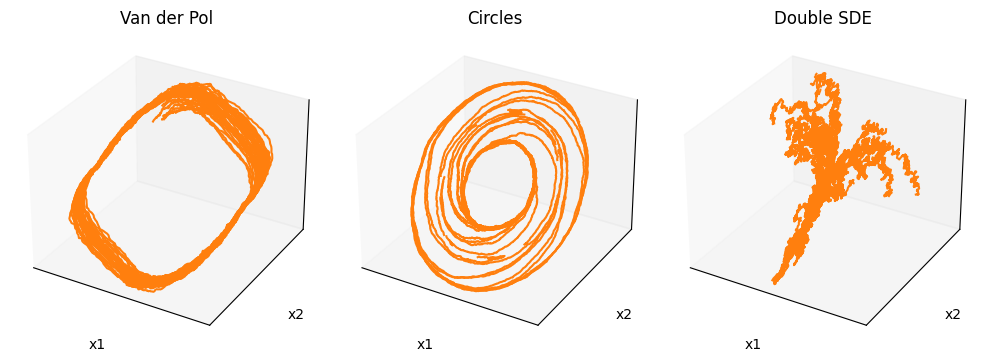

In [14]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,5))# = plt.subplots(nrows=1,ncols=3,figsize=(10,5),projection=3d)
labs = ['Van der Pol', 'Circles', 'Double SDE']
for ii,(trajs,label) in enumerate(zip(projected2d,labs)):

    ax = fig.add_subplot(1,3,ii+1,projection='3d')
    for traj in trajs:
        ax.plot(traj[:,0],traj[:,1],traj[:,2],color='tab:orange')

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('x3')
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xticks([])
    ax.set_title(label)
plt.tight_layout()
plt.show()
plt.close()

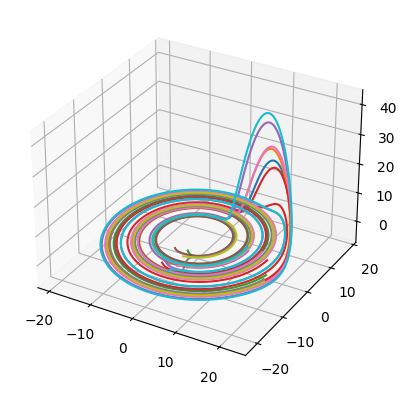

In [8]:
fig = plt.figure()

ax = fig.add_subplot(111,projection='3d')
for traj in rosslers:
    ax.plot(traj[:,0],traj[:,1],traj[:,2])
plt.show()
plt.close()
    

In [11]:
import numpy as np
video = Balls(coeffs=np.array([[-1,-3],[-3,1]]))

trajs_vid = video.generate(n=20,T=5,dt=0.01,sigma=0.01)
circles_vid = video.traj_to_movie(trajs_vid,image_shape=(64,64),radius=5,blur=True)

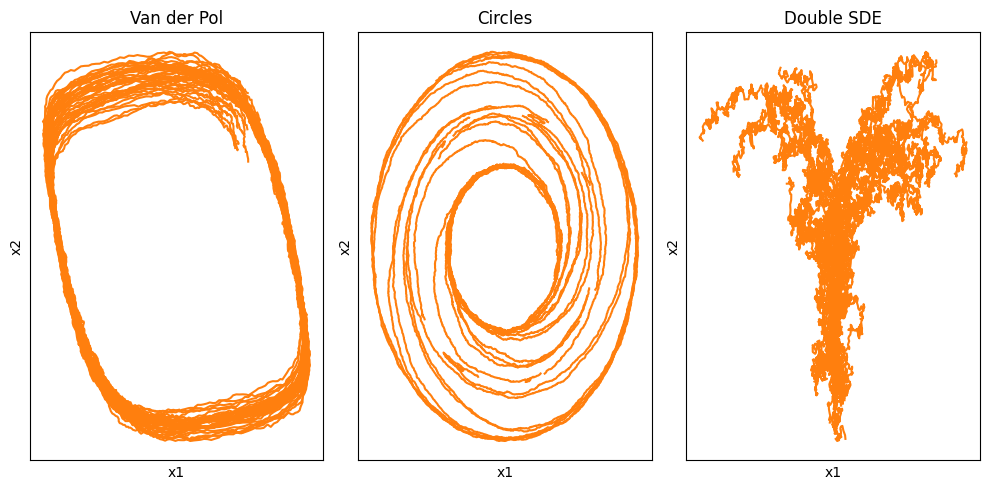

In [12]:
fig,axs = plt.subplots(nrows=1,ncols=3,figsize=(10,5))
labs = ['Van der Pol','Circles', 'Double SDE']
for ax,trajs,label in zip(axs,trajs2d,labs):

    for traj in trajs:
        ax.plot(traj[:,0],traj[:,1],color='tab:orange')

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(label)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()
plt.close()

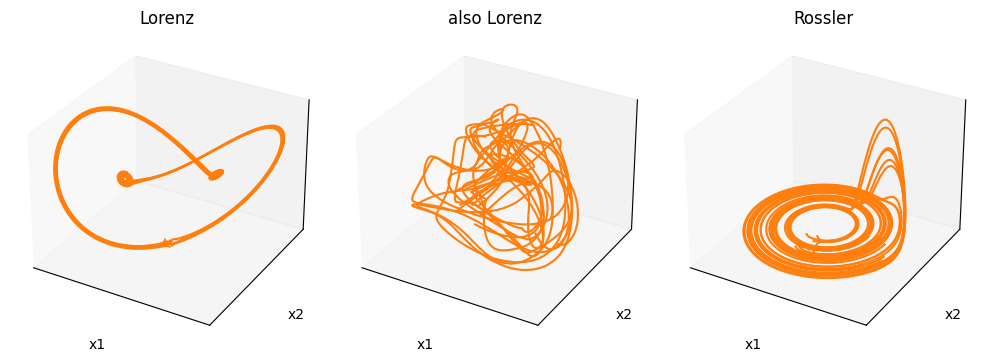

In [13]:
fig = plt.figure(figsize=(10,5))# = plt.subplots(nrows=1,ncols=3,figsize=(10,5),projection=3d)
labs = ['Lorenz', 'also Lorenz', 'Rossler']
for ii,(trajs,label) in enumerate(zip(trajsHigherd,labs)):

    ax = fig.add_subplot(1,3,ii+1,projection='3d')
    for traj in trajs:
        ax.plot(traj[:,0],traj[:,1],traj[:,2],color='tab:orange')

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('x3')
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xticks([])
    ax.set_title(label)
plt.tight_layout()
plt.show()
plt.close()

(500, 1, 64, 64)


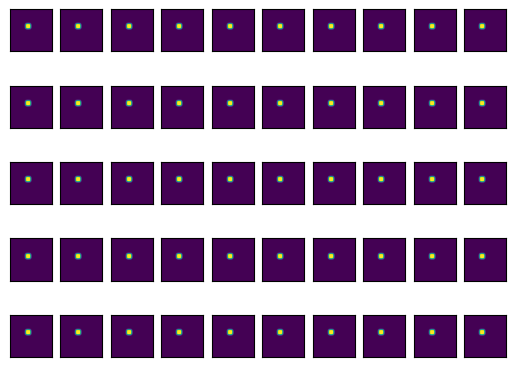

In [14]:

fig,axs = plt.subplots(nrows=5,ncols=10)
axs = axs.flatten()
for movi in circles_vid:
    print(movi.shape)
    for ii,frame in enumerate(movi):
        if ii < 50:
            
            
            axs[ii].imshow(frame.squeeze())
            axs[ii].set_xticks([])
            axs[ii].set_yticks([])
            #axs[ii].set_visible(False)
            #plt.show()
            #plt.close()

        else:
            break

    plt.show()
    plt.close()
    break

NameError: name 'circles_transf' is not defined

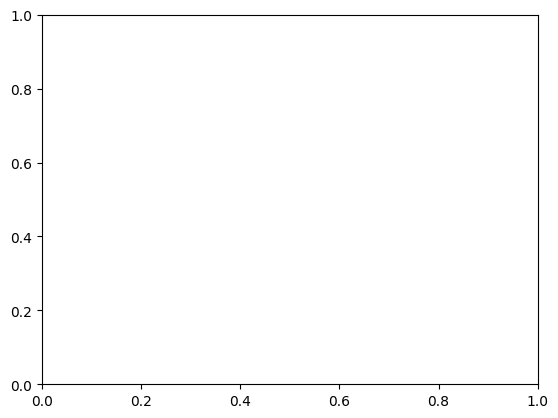

In [15]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot()
for c in circles_transf:
    #print(c.shape)
    ax.plot(c[:,0],c[:,1],color='tab:orange')

ax.set_xlabel('x1')
#for c in sde2:
    #print(c.shape)
#    ax.plot(c[:,0],c[:,1],color='tab:blue')
#ax.scatter(generator.center1[0],generator.center1[1],color='red',s=100,zorder=5)
#ax.scatter(generator.center2[0],generator.center2[1],color='red',s=100,zorder=5)

ax.set_ylabel('x2')


plt.show()
plt.close()

In [12]:
from scipy.ndimage import gaussian_filter
def generate_OU_balls(n=100,T=1,dt=0.001,imshape=(64,64),radius=2,blur=False,
                        coeffs =np.array([-4,-4]),
                        sigma=0., 
                        seed=1040):
    
    
    trajectories=[]
    t = np.arange(0,T,dt)
    gen = np.random.default_rng(seed=seed)
    
    def f(x,t):
    
        return coeffs @ x 
    
    def g(x,t):
    
        return sigma*np.eye(2)
    
    def dW(dt):
    
        return gen.multivariate_normal(mean=np.zeros((2,)),cov=dt*np.eye(2))
    
    
    for ii in range(n):
    
        xnot = np.zeros((2,))
        
        xx = [xnot]
        
        for jj in range(1,len(t)+1):
    
            x = xx[jj-1]
            tt = t[jj-1]

            xx.append(x + f(x,tt)*dt + g(x,tt)@dW(dt))
    
        xx = np.vstack(xx)
        xx = (xx - xx.min())/(xx.max() - xx.min())
        #xx -= np.amin(xx)
        #xx /= np.amax(xx)
    
        trajectories.append(xx)
    
    movies = traj_to_movie(trajectories,imshape,radius,blur)
    
    return trajectories,movies
    
def traj_to_movie(trajectories,image_shape,radius,blur=False):
    
    """
    converts a latent trajectory to a movie
    """
    
    movies = []
    gX,gY = np.meshgrid(np.linspace(-1,1,2*radius),np.linspace(-1,1,2*radius))
    ball = (gX**2 + gY**2 < 1)
    image_shape = np.array(image_shape)
    
    for traj in trajectories:
        frames = np.zeros((len(traj),1,image_shape[0],image_shape[1]))
    
        for point in range(len(traj)):
    
            ballCenter = (traj[point,:] *(image_shape - 2*radius)).astype(int) + radius
            print(traj[point])
            print(ballCenter)
            frames[point,0,ballCenter[0]-radius:ballCenter[0] + radius, ballCenter[1]-radius:ballCenter[1] + radius] += ball
            if blur:
                frames[point,0,:,:] = gaussian_filter(frames[point,0,:,:],sigma=radius*4,truncate=0.05)
                
    
        movies.append(frames)
    return movies

In [22]:
trajs,movies = generate_OU_balls(n=5,T=5,dt=0.01,imshape=(64,64),radius=5,blur=True,
						coeffs = np.array([-1,-4]),
						sigma=10, 
						seed=1040)


NameError: name 'movies' is not defined

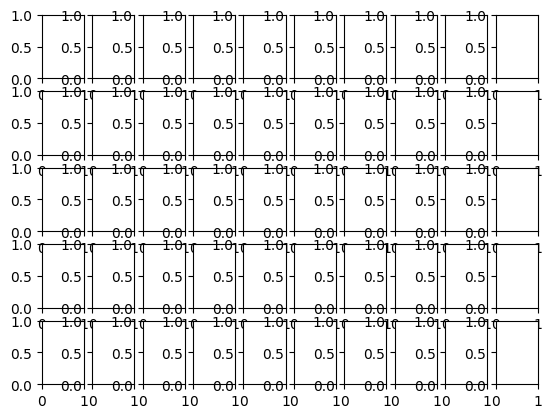

In [14]:

fig,axs = plt.subplots(nrows=5,ncols=10)
axs = axs.flatten()
for movi in movies:
    print(movi.shape)
    for ii,frame in enumerate(movi):
        if ii < 50:
            
            
            axs[ii].imshow(frame.squeeze())
            #plt.show()
            #plt.close()

        else:
            break

    plt.show()
    plt.close()
    break

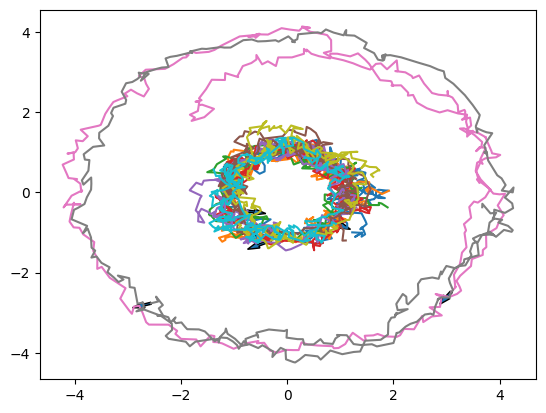

In [5]:
import matplotlib.pyplot as plt
ax = plt.gca()

for swirl in swirls:
    ax.plot(swirl[:,0],swirl[:,1])
    #ax.scatter(swirl[-1,0],swirl[-1,1])
    #print(swirl.shape)
    dxy = np.diff(swirl,axis=0)
    #print(dxy.shape)
    ax.arrow(swirl[-1,0], swirl[-1,1],dxy[-1,0],dxy[-1,1],width=0.05)
plt.show()
plt.close()


In [138]:
lorenz = generate_stochastic_lorenz96(n=50,T=3,dt=0.01, d=6,coeffs=[8,0.5])


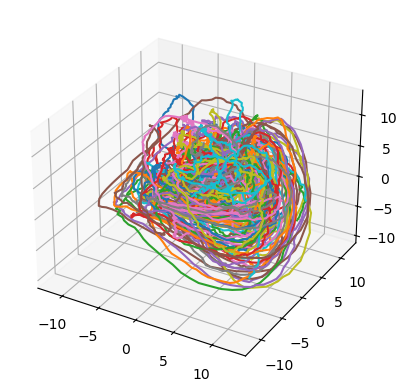

In [139]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

for traj in lorenz:
    ax.plot(traj[:,0],traj[:,1],traj[:,2])
    
plt.show()
plt.close()

In [7]:
lorenz = generate_stochastic_lorenz(n=50,T=3,dt=0.01, coeffs=[10,28,8/3,0.,0.,0.])
rossler = generate_stochastic_rossler(n=50,T=20,dt=0.01,coeffs=[0.2,0.2,5.7,0.,0.,0.])


NameError: name 'generate_stochastic_lorenz' is not defined

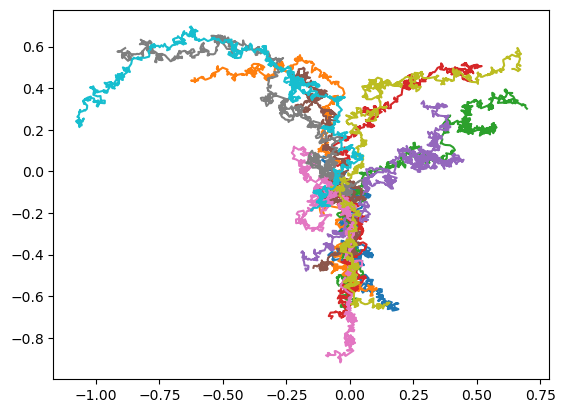

In [17]:
ax = plt.gca()
for s in sde2:
    ax.plot(s[:,0],s[:,1])
#ax.vlines([0],ymin=-0.6,ymax=0.6,color='k')
plt.show()
plt.close()

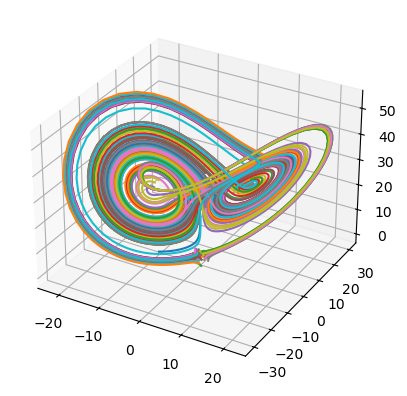

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

for traj in lorenz:
    ax.plot(traj[:,0],traj[:,1],traj[:,2])
    
plt.show()
plt.close()


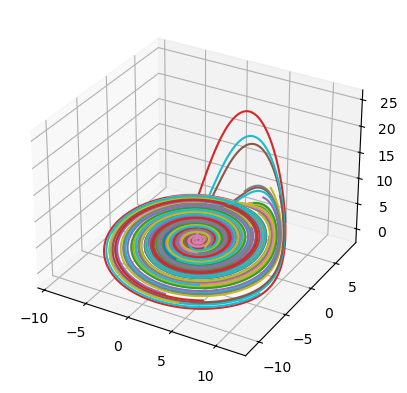

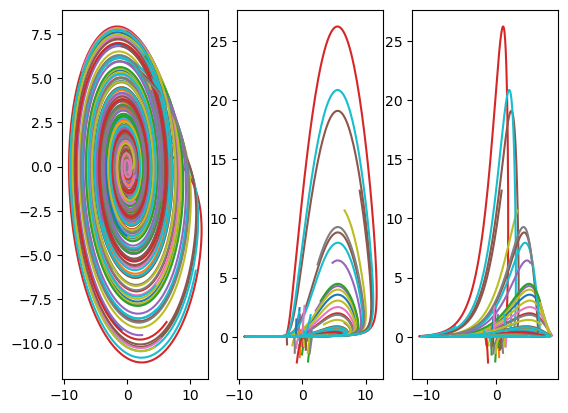

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

for traj in rossler:
    ax.plot(traj[:,0],traj[:,1],traj[:,2])
    
plt.show()
plt.close()

fig,axs = plt.subplots(nrows=1,ncols=3)
for traj in rossler:
    axs[0].plot(traj[:,0],traj[:,1])
    axs[1].plot(traj[:,0],traj[:,2])
    axs[2].plot(traj[:,1],traj[:,2])
plt.show()
plt.close()

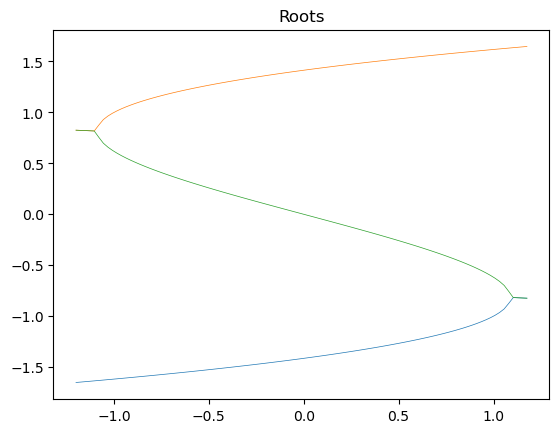

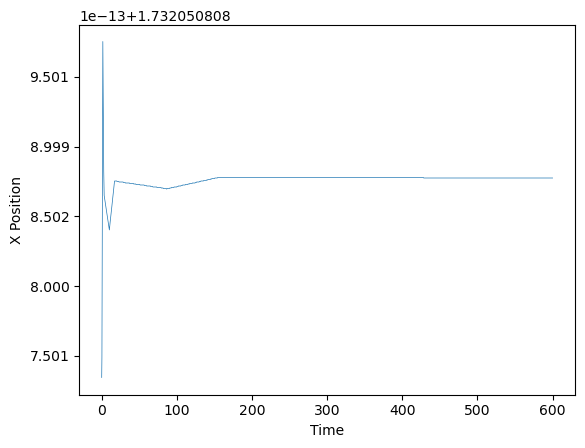

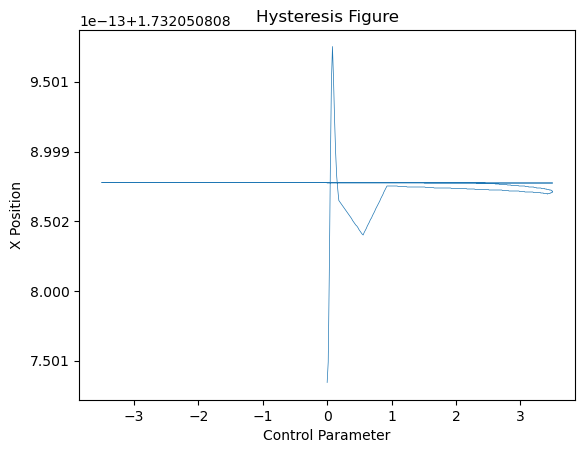

In [46]:
import numpy as np
from scipy import integrate
from scipy import signal
from matplotlib import pyplot as plt
 
plt.close('all')
T = 400
Amp = 3.5
xc = np.zeros((100,))
X,Y,Z = np.zeros((100,)),np.zeros((100,)),np.zeros((100,))
def solve_flow(y0,c0,lim = [-3,3,-3,3]):
 
    def flow_deriv(x_y, t, c0):
        #"""Compute the time-derivative of a Medio system."""
        x, y = x_y
 
        return [y,-0.5*y - x**3 + 2*x + x]# + x*(2*np.pi/T)*Amp*np.cos(2*np.pi*t/T) + Amp*np.sin(2*np.pi*t/T)]
 
    tsettle = np.linspace(0,T,101)   
    yinit = y0;
    x_tsettle = integrate.odeint(flow_deriv,yinit,tsettle,args=(T,))
    y0 = x_tsettle[100,:]
     
    t = np.linspace(0, 1.5*T, 2001)
    x_t = integrate.odeint(flow_deriv, y0, t, args=(T,))
    c  = Amp*np.sin(2*np.pi*t/T)
         
    return t, x_t, c
 
eps = 0.0001
 
for loop in range(0,100):
    c = -1.2 + 2.4*loop/100 + eps;
    xc[loop]=c
     
    coeff = [-1, 0, 2, c]
    y = np.roots(coeff)
     
    xtmp = np.real(y[0])
    ytmp = np.real(y[1])
     
    X[loop] = np.min([xtmp,ytmp])
    Y[loop] = np.max([xtmp,ytmp])
    Z[loop]= np.real(y[2])
 
 
ax = plt.gca()
lines = plt.plot(xc,X,xc,Y,xc,Z)
plt.setp(lines, linewidth=0.5)
plt.title('Roots')

plt.show()
plt.close()
 
y0 = [1.9, 0]
c0 = -2.
 
t, x_t, c = solve_flow(y0,c0)
y1 = x_t[:,0]
y2 = x_t[:,1]
 
ax = plt.gca()
lines = plt.plot(t,y1)
plt.setp(lines, linewidth=0.5)
plt.ylabel('X Position')
plt.xlabel('Time')
plt.show()
plt.close()

 
ax = plt.gca()
lines = plt.plot(c,y1)
plt.setp(lines, linewidth=0.5)
plt.ylabel('X Position')
plt.xlabel('Control Parameter')
plt.title('Hysteresis Figure')
plt.show()
plt.close()